# Toto anomaly fine-tuning loss curves — maskloss v2 + HS

Plots the training (and eval, if present) curves logged to `trainer_state.json`
by `finetune_toto_anomaly.py`:

- **Total loss** = `L_good + lambda * L_bad_term`
- **Pinball loss** (Toto CombinedLoss), split normal vs anomaly steps (`normal_loss` / `anomaly_loss`)
- **MSE**, split normal vs anomaly steps (`mse_normal_step` / `mse_anomaly_step`)
- **Anomaly hinge-active fraction** and **learning rate** (diagnostics)

Point `RUN_DIR` at a run's output folder (the dir containing `trainer_state.json`).
Eval curves (`eval_val_*`, `eval_test_*`) are auto-detected and overlaid.

In [7]:
import json, glob, os
import pandas as pd
import matplotlib.pyplot as plt

# Run to inspect. Leave RUN_DIR = None to auto-pick the most recent run folder
# (any dir containing trainer_state.json); or set it to a specific output folder.
RUN_DIR = None

if RUN_DIR is None:
    found = glob.glob("**/trainer_state.json", recursive=True) + \
            (["trainer_state.json"] if os.path.exists("trainer_state.json") else [])
    assert found, "no trainer_state.json under the current directory"
    state_path = max(set(found), key=os.path.getmtime)
else:
    state_path = os.path.join(RUN_DIR, "trainer_state.json")
assert os.path.exists(state_path), f"not found: {state_path}"
print("reading:", state_path)

with open(state_path) as f:
    hist = json.load(f)["log_history"]

df = pd.DataFrame(hist)
print(f"{len(df)} log entries, steps {int(df['step'].min())}..{int(df['step'].max())}")
print("columns:", list(df.columns))
df.tail(3)

reading: toto-single-stage_mtsbench_HS/trainer_state.json
26 log entries, steps 10..250
columns: ['step', 'loss', 'lr', 'normal_loss', 'mse_normal_step', 'anomaly_loss', 'mse_anomaly_step', 'anomaly_active_frac', 'eval_val_normal_loss', 'eval_val_mse_normal_step', 'eval_val_anomaly_loss', 'eval_val_mse_anomaly_step', 'eval_val_anomaly_active_frac', 'eval_val_loss', 'eval_test_normal_loss', 'eval_test_mse_normal_step', 'eval_test_anomaly_loss', 'eval_test_mse_anomaly_step', 'eval_test_anomaly_active_frac', 'eval_test_loss']


,step,loss,lr,normal_loss,mse_normal_step,anomaly_loss,mse_anomaly_step,anomaly_active_frac,eval_val_normal_loss,eval_val_mse_normal_step,eval_val_anomaly_loss,eval_val_mse_anomaly_step,eval_val_anomaly_active_frac,eval_val_loss,eval_test_normal_loss,eval_test_mse_normal_step,eval_test_anomaly_loss,eval_test_mse_anomaly_step,eval_test_anomaly_active_frac,eval_test_loss
23,230,2.7899,0.0001,-0.8745,1.0491,-0.5127,3.507600e+00,0.9306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,240,2.7883,0.0001,-0.7105,0.4993,0.1327,3.745889e+15,0.9186,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,250,2.3657,0.0001,-0.9169,0.6510,-0.9957,1.448600e+00,0.9458,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
def plot_split(normal_col, anomaly_col, title, ylabel):
    """Plot the train normal/anomaly metric pair plus any eval variants.

    Train series use the bare column names; eval variants are the same names
    with an eval_[val_|test_] prefix (e.g. eval_val_normal_loss)."""
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for col, color in [(normal_col, "#2ca02c"), (anomaly_col, "#d62728")]:
        if col in df:
            s = df[df[col].notna()]
            if len(s):
                ax.plot(s["step"], s[col], color=color, label=f"train {col}")
        for c in [c for c in df.columns
                  if c.startswith("eval") and c.endswith(col)]:
            s = df[df[c].notna()]
            if len(s):
                ax.plot(s["step"], s[c], marker="o", ms=3, ls="--", label=c)
    ax.set_xlabel("step"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()


def plot_single(col, title, ylabel):
    """Plot one train metric plus any eval_* variants ending in that name."""
    if col not in df:
        print(f"(no column {col})"); return
    fig, ax = plt.subplots(figsize=(9, 4.5))
    s = df[df[col].notna()]
    ax.plot(s["step"], s[col], label=f"train {col}")
    for c in [c for c in df.columns if c.startswith("eval") and c.endswith(col)]:
        s2 = df[df[c].notna()]
        if len(s2):
            ax.plot(s2["step"], s2[c], marker="o", ms=3, ls="--", label=c)
    ax.set_xlabel("step"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

## Total loss

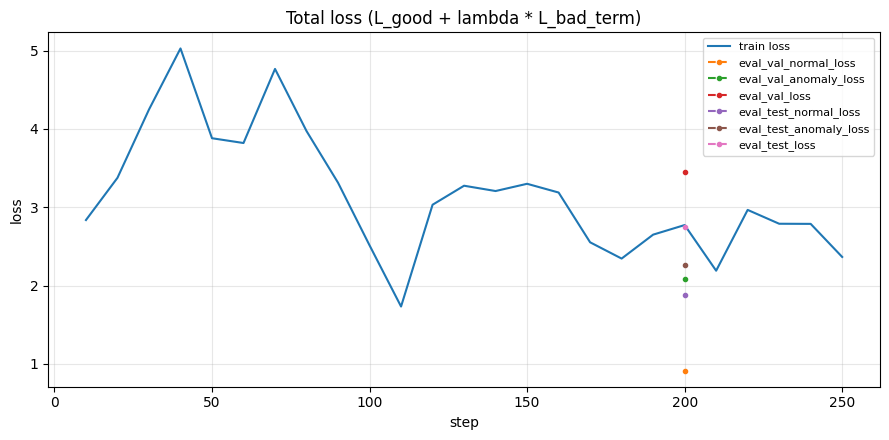

In [9]:
plot_single("loss", "Total loss (L_good + lambda * L_bad_term)", "loss")

## Pinball loss — normal vs anomaly steps

Normal (green) should trend **down** (predict normal well); anomaly (red) is pushed
**up** toward the margin by the hinge term, so it typically sits higher / rises early
then plateaus once the margin is satisfied.

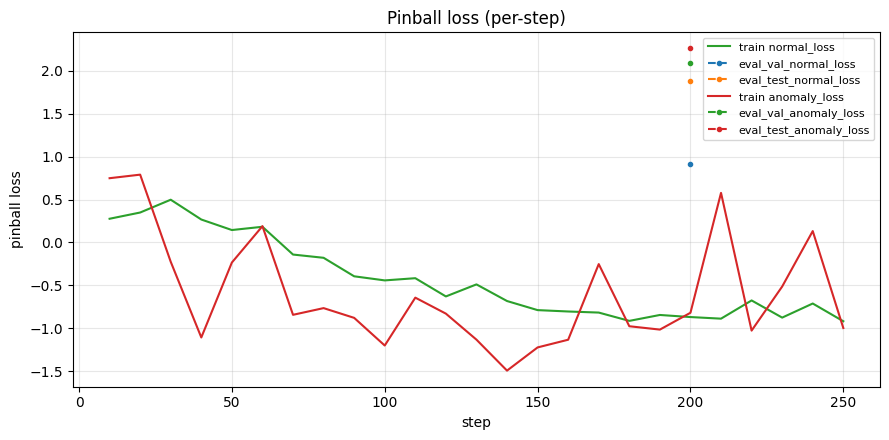

In [10]:
plot_split("normal_loss", "anomaly_loss",
           "Pinball loss (per-step)", "pinball loss")

## MSE — normal vs anomaly steps

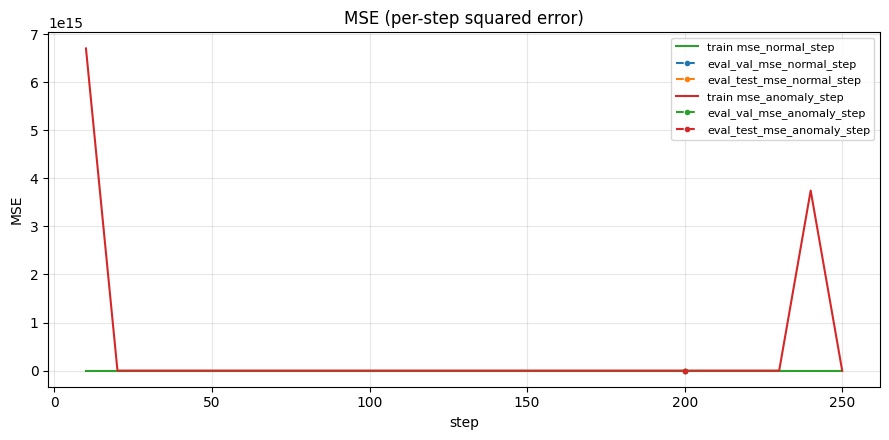

In [11]:
plot_split("mse_normal_step", "mse_anomaly_step",
           "MSE (per-step squared error)", "MSE")

## Diagnostics — hinge-active fraction & learning rate

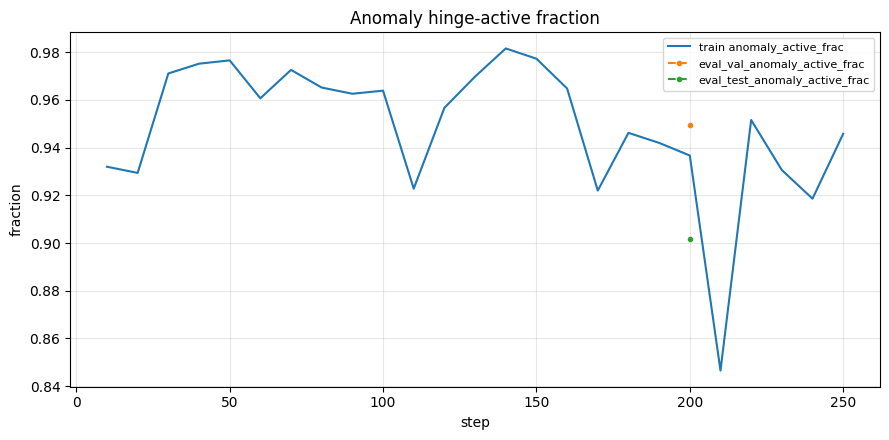

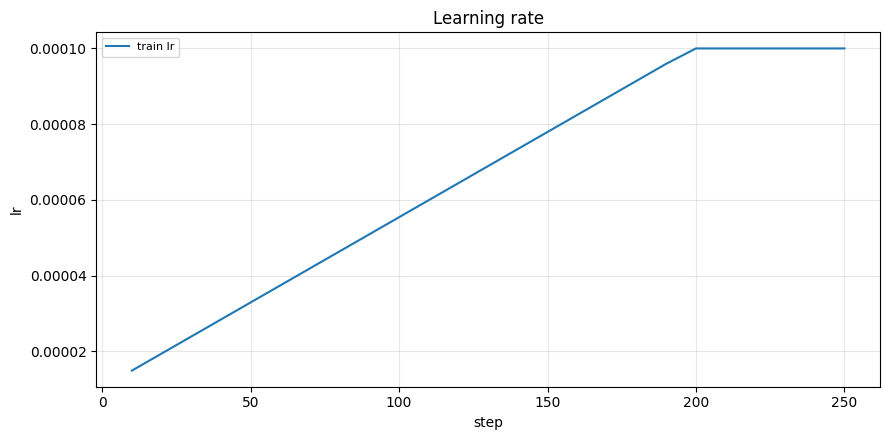

In [12]:
plot_single("anomaly_active_frac", "Anomaly hinge-active fraction", "fraction")
plot_single("lr", "Learning rate", "lr")